In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# Load 028 transect
transect = load_transect(config.TRANSECT_028_OUTPUT)

transect.list_files()

# Select 028_5 for NDI analysis
cube = transect.select_files(
    [
        "rad_uhi_20241029_125028_1",
        "rad_uhi_20241029_125028_2",
        "rad_uhi_20241029_125028_3",
        "rad_uhi_20241029_125028_4",
        "rad_uhi_20241029_125028_5",
    ]
)
# cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_125028_1  | shape=(1329, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_125028_2  | shape=(2011, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_125028_3  | shape=(2282, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_125028_4  | shape=(2457, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_125028_5  | shape=(1948, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_125028_1
  rad_uhi_20241029_125028_1: Using GRIDDED format (T=1329, S=968)
   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_2
  rad_uhi_20241029_125028_2: Using GRIDDED format (T=2011, S=968)
   • rad_uhi_20241029_125028_3
   • rad_uhi_20241029_125028_3
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
  rad_uhi_20241029_125028_3: Using GRIDDED format (T=2282, S=968)
   • rad_uhi_20241029_125028_4
   • rad_uhi_

In [3]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 5 files...
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_1: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_2: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_3: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_4: window=500, strength=1.0
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_125028_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[0.00000000e+00, 8.00363868e-02, 3.38807702e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         9.79862548e-03, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 6.24412894e-01, 0.00000000e+00, ...,
         2.43312144e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.49576187e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.18552887e+00, ...,
         2.34972164e-01, 0.00000000e+00, 0.00000000e+00],
        [9.47257459e-01, 0.00000000e+00, 0.00000000e+00, ...,
         3.01917344e-01, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.15298668e+02, 1.14839525e+01, 3.45664215e-03],
        [0.00000000e+00, 1.00000000e+00, 9.11504328e-01, ...,
         2.32659373e-02, 2.43540382e+00, 4.57144403e+00],
        [0.00000000e+00, 

In [4]:
cube.import_rois("./ROIs/028_new.json")
cube.list_rois()

roi_1 = [
    "1_halo",
    "1_arms",
    "1_dark",
    "1_bomb",
    "sediment",
]
roi_2 = [
    "2_halo",
    "rust",
    "sediment",
    "2_dark",
    "2_bomb",
]
roi_3 = [
    "3_halo",
    "3_dark",
    "sediment",
    "3_bomb",
]
roi_pit = [
    "sediment",
    "dark_pits",
]

roi_halo = [
    "sediment",
    "1_halo",
    "2_halo",
    "3_halo",
]

roi_dark = [
    "sediment",
    "1_dark",
    "2_dark",
    "3_dark",
]

roi_bomb = [
    "sediment",
    "1_bomb",
    "2_bomb",
    "3_bomb",
]


roi_training_binary = [
    "sediment",
    "rust",
]

roi_training = [
    "sediment",
    "rust",
    "1_dark",
    "2_dark",
    "3_dark",
    "1_halo",
    "2_halo",
    "3_halo",
]

📂 Imported 14 ROIs from ./ROIs/028_new.json

📂 ROI Collection (14 ROIs):
 1. 'rust': 58 pixels
     Slit range:  193 - 222
     Track range: 1255 - 1261
 2. 'sediment': 541 pixels
     Slit range:   28 - 967
     Track range: 3604 - 9735
 3. '1_halo': 50 pixels
     Slit range:  575 - 649
     Track range: 5154 - 5168
 4. '1_arms': 135 pixels
     Slit range:  549 - 682
     Track range: 5146 - 5178
 5. '1_dark': 149 pixels
     Slit range:  538 - 688
     Track range: 5150 - 5179
 6. '1_bomb': 148 pixels
     Slit range:  595 - 636
     Track range: 5156 - 5163
 7. '2_dark': 145 pixels
     Slit range:  150 - 280
     Track range: 1250 - 1271
 8. '2_halo': 96 pixels
     Slit range:  174 - 240
     Track range: 1253 - 1266
 9. '3_halo': 143 pixels
     Slit range:  721 - 786
     Track range: 5587 - 5600
10. '3_dark': 130 pixels
     Slit range:  723 - 809
     Track range: 5583 - 5604
11. '3_bomb': 79 pixels
     Slit range:  742 - 764
     Track range: 5590 - 5597
12. 'dark_pits': 6

In [5]:
# Define crop regions (UPDATED coordinates from user)
crop_regions = [
    {
        "name": "Crop 1 (Bomb 2 - Rust)",
        "track": 1258,
        "slit": 250,  # UPDATED from 212
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 2 (Bomb 3)",
        "track": 5592,
        "slit": 700,  # UPDATED from 765
        "width": 500,
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 3 (Bomb 1)",
        "track": 5160,
        "slit": 613,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
    {
        "name": "Crop 4 (Dark pits)",
        "track": 717,
        "slit": 385,
        "width": 500,  # UPDATED from 400
        "aspect_ratio": 4,  # UPDATED from 3.5
    },
]

In [6]:
# # 🔧 MONKEYPATCH: Clean image output (no axes, labels, titles, colorbars)
# # This removes all plot decorations to get JUST THE IMAGE

# import matplotlib.pyplot as plt
# from utils.uhi.georef import CombinedTransectCube

# # Store original plot_rgb method
# _original_plot_rgb = CombinedTransectCube.plot_rgb


# def plot_rgb_clean(*args, **kwargs):
#     """
#     Wrapper that calls original plot_rgb but removes all decorations.
#     Results in clean image output - JUST THE FIGURE, nothing else.
#     """
#     # Call original function
#     result = _original_plot_rgb(*args, **kwargs)

#     # Get current figure and axes
#     fig = plt.gcf()
#     ax = plt.gca()

#     # Remove ALL decorations for clean image output
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.set_title("")
#     ax.axis("off")  # This removes tick marks, labels, and frame

#     # Remove ALL text annotations
#     for txt in ax.texts:
#         txt.set_visible(False)

#     # Remove colorbar if present (any extra axes)
#     if len(fig.axes) > 1:
#         for axis in fig.axes[1:]:
#             axis.remove()

#     # Remove whitespace around image
#     fig.tight_layout(pad=0)
#     plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

#     return result


# # Apply monkeypatch
# CombinedTransectCube.plot_rgb = plot_rgb_clean

# print("✅ Clean image monkeypatch applied!")
# print("   All plots will show JUST THE IMAGE - no axes, labels, titles, or colorbars")
# print("   To revert: restart kernel")


📍 Crop 1 (Bomb 2 - Rust)
   Track: 1258, Slit: 250
   Width: 500, Aspect Ratio: 4

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 132

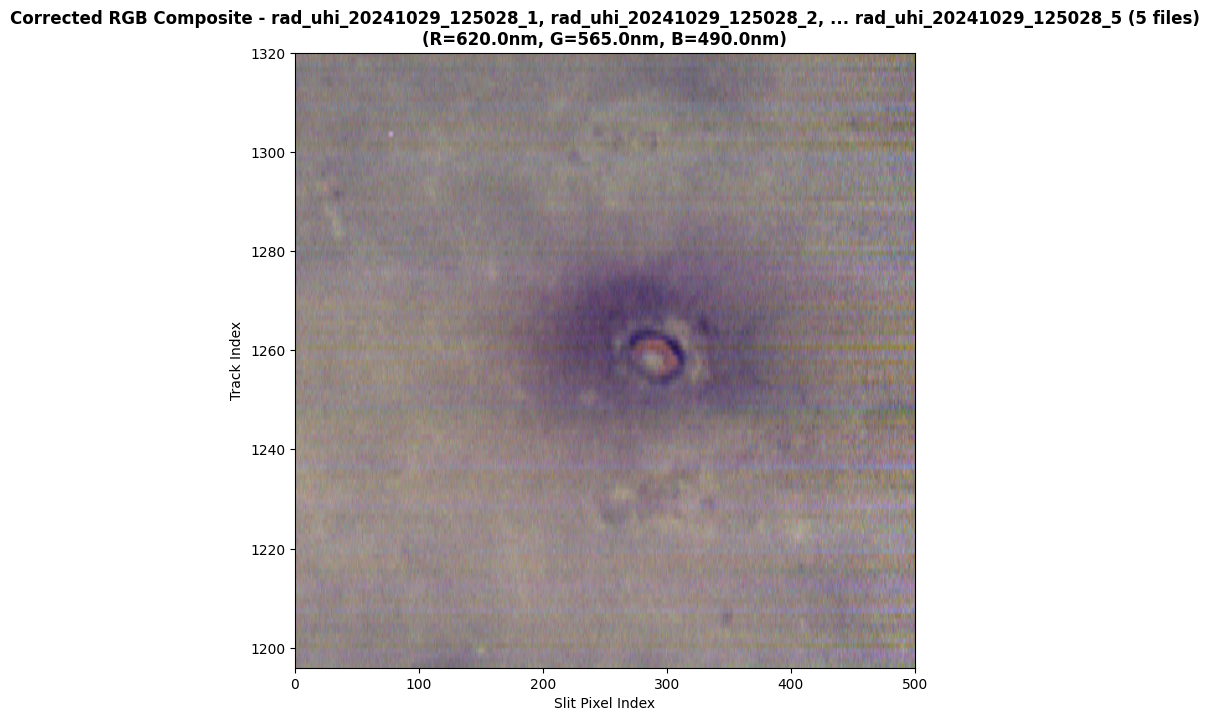

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
📐 Crop center: global track 1258 → local track 1258, slit 250
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [1196:1320], slit [0:500]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[0, 500], y=[1196, 1320]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


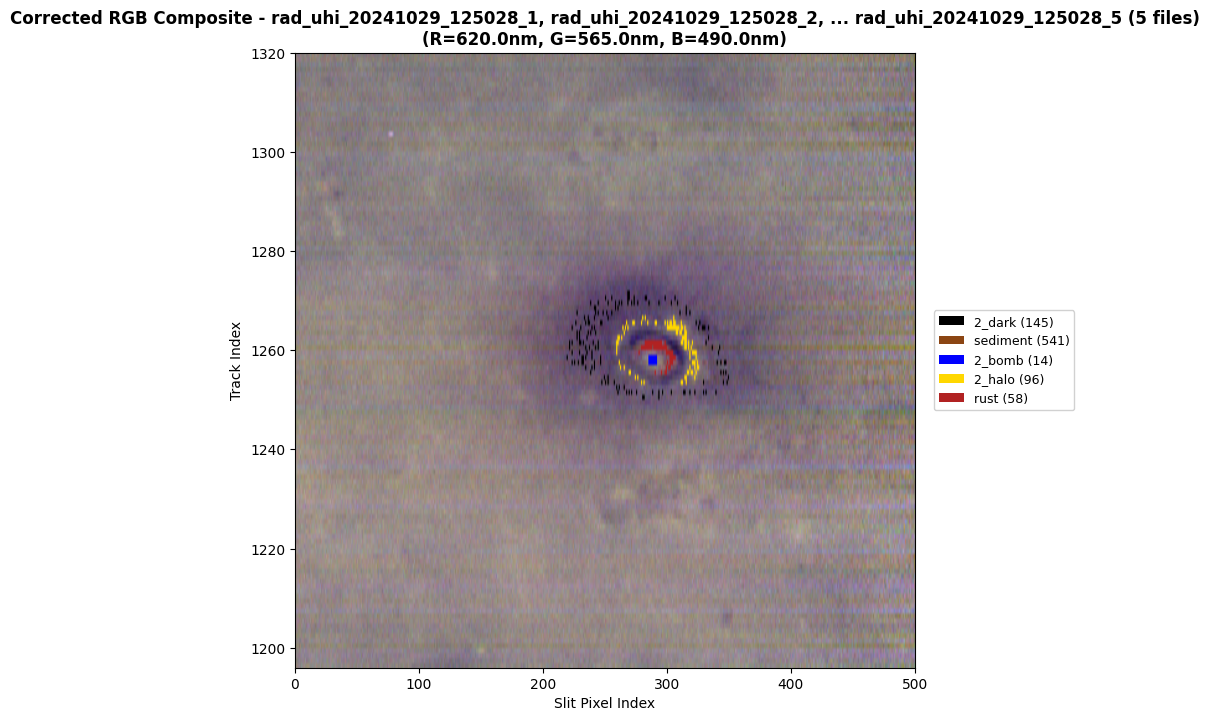


📍 Crop 2 (Bomb 3)
   Track: 5592, Slit: 700
   Width: 500, Aspect Ratio: 4

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 56

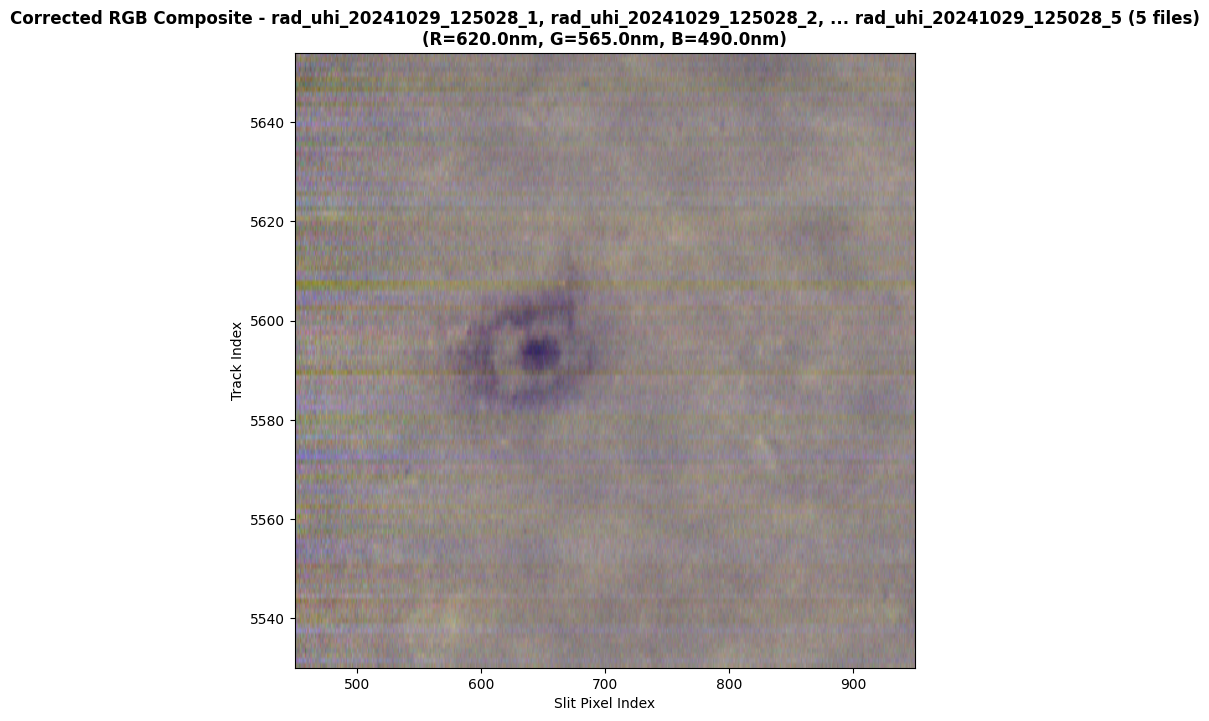

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
📐 Crop center: global track 5592 → local track 5592, slit 700
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5530:5654], slit [450:950]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[450, 950], y=[5530, 5654]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


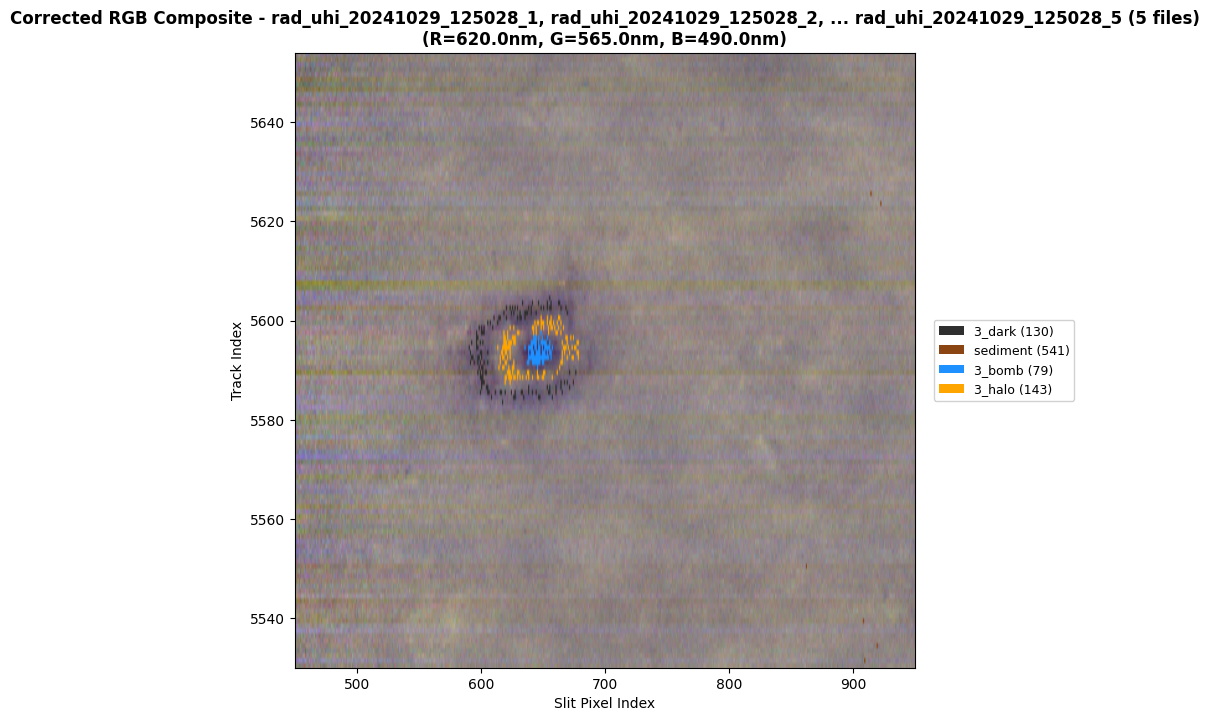


📍 Crop 3 (Bomb 1)
   Track: 5160, Slit: 613
   Width: 500, Aspect Ratio: 4

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 52

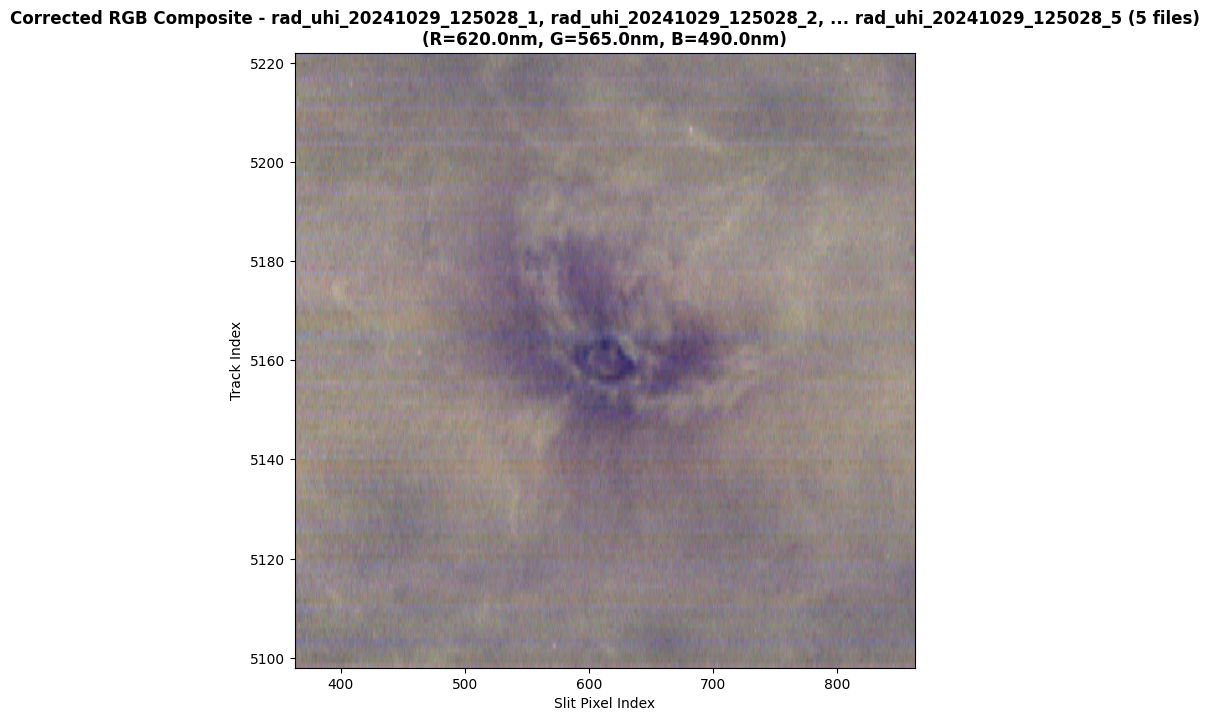

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
📐 Crop center: global track 5160 → local track 5160, slit 613
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [5098:5222], slit [363:863]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[363, 863], y=[5098, 5222]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


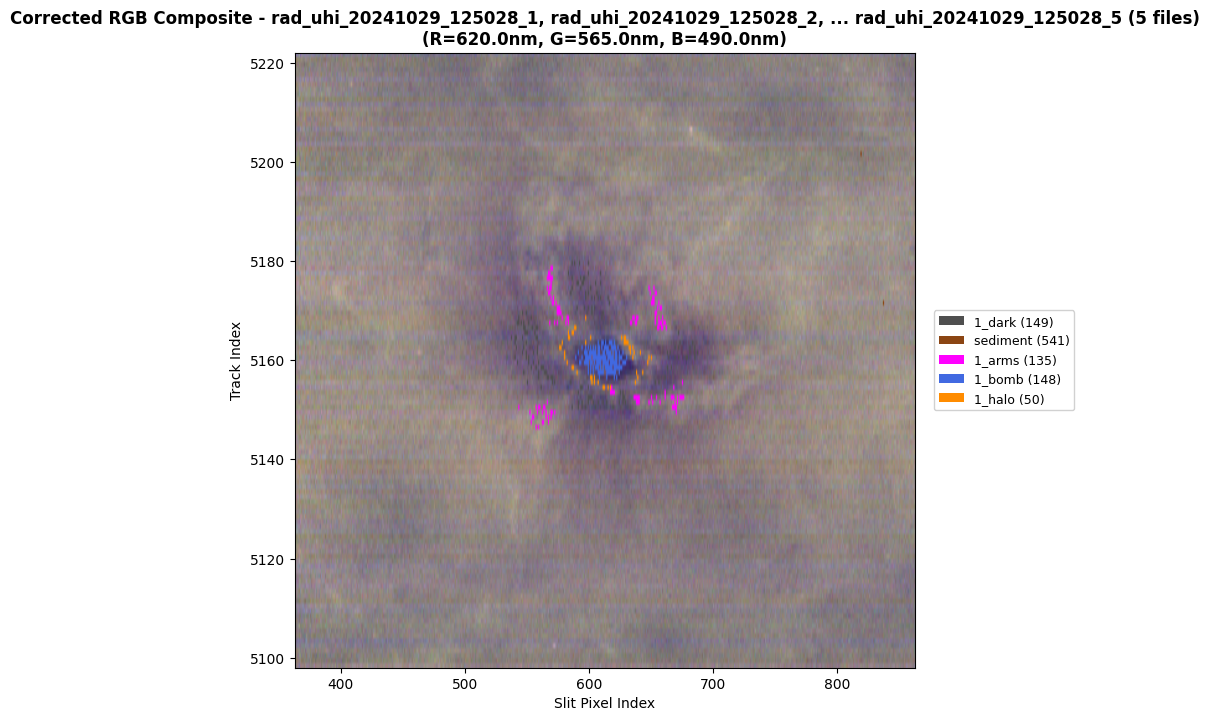


📍 Crop 4 (Dark pits)
   Track: 717, Slit: 385
   Width: 500, Aspect Ratio: 4

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=best, roi_overlay_mode=markers
✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Imag

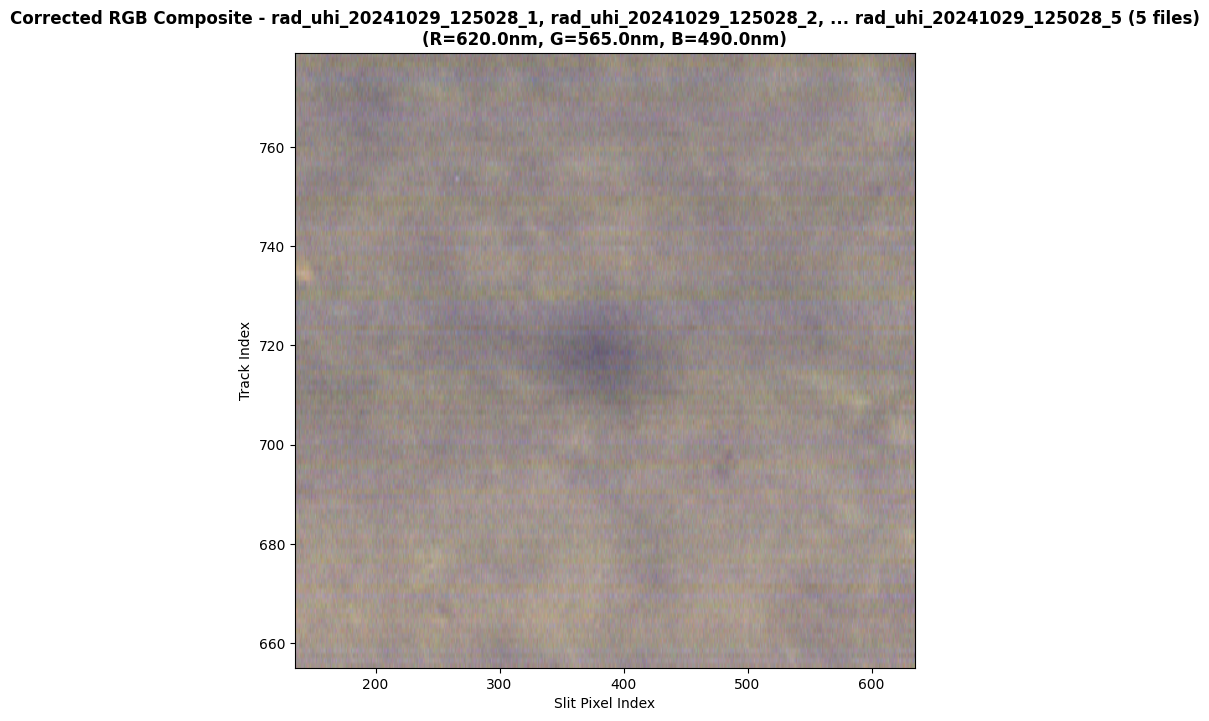

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid
📐 Crop center: global track 717 → local track 717, slit 385
   Aspect ratio correction: 4.00:1 (track:slit)
   Slit pixels: 500, Track pixels: 124
🔍 Crop applied: track [655:779], slit [135:635]
   Resulting shape: (124, 500, 3)
📊 Extent: x=[135, 635], y=[655, 779]
📐 Image shape after transformations: (124, 500, 3)
🐛 DEBUG legend: has_overlays=True, roi_legend_loc=outside, roi_overlay_mode=solid


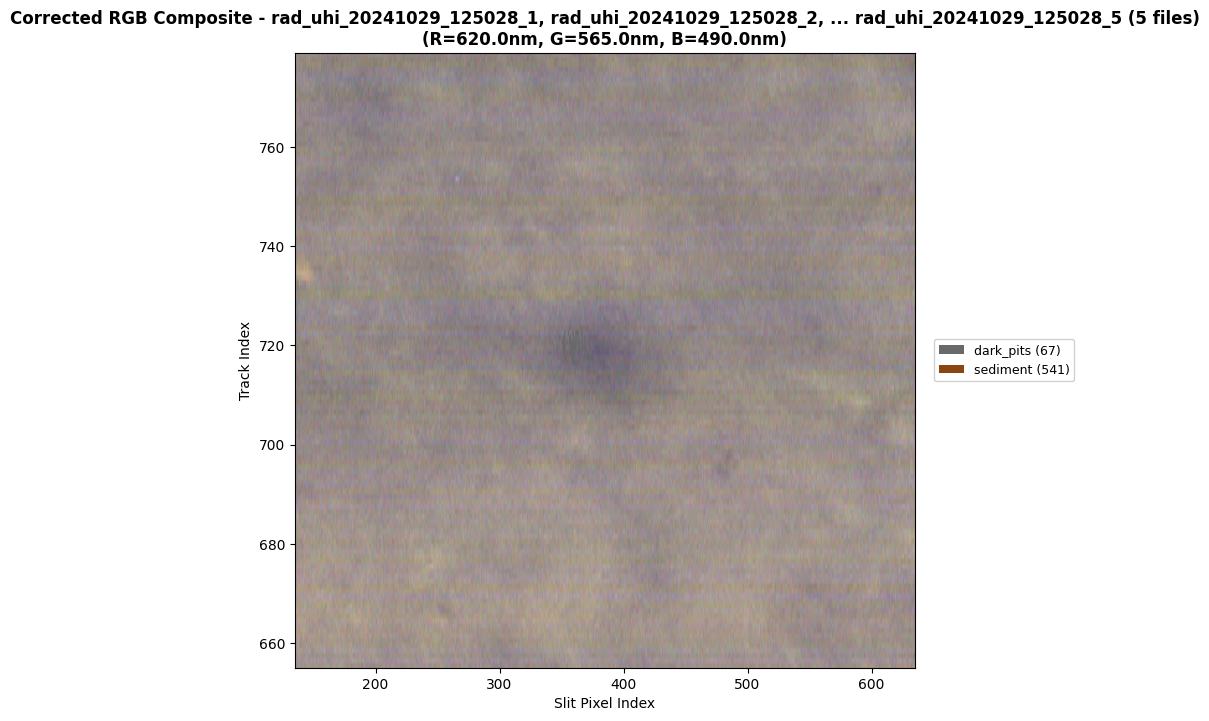


✅ All 4 crop regions plotted!


In [7]:
# Plot all crop regions defined above
for crop in crop_regions:
    print(f"\n{'='*60}")
    print(f"📍 {crop['name']}")
    print(f"   Track: {crop['track']}, Slit: {crop['slit']}")
    print(f"   Width: {crop['width']}, Aspect Ratio: {crop['aspect_ratio']}")
    print(f"{'='*60}\n")

    # Determine which ROI collection to use based on crop name
    if "Bomb 1" in crop["name"]:
        roi_collection = roi_1
    elif "Bomb 2" in crop["name"]:
        roi_collection = roi_2
    elif "Bomb 3" in crop["name"]:
        roi_collection = roi_3
    elif "Dark pits" in crop["name"]:
        roi_collection = roi_pit
    else:
        roi_collection = None

    # Plot RGB without ROIs
    cube.plot_rgb(
        use_corrected=True,
        flip_axes=True,
        flip_horizontal=True,
        crop_center_track=crop["track"],
        crop_center_slit=crop["slit"],
        crop_width=crop["width"],
        show_file_boundaries=False,
        crop_aspect_ratio=crop["aspect_ratio"],
        display_aspect_ratio=4.0,
    )

    # Plot RGB with ROIs overlay
    if roi_collection:
        cube.plot_rgb(
            use_corrected=True,
            flip_axes=True,
            flip_horizontal=True,
            crop_center_track=crop["track"],
            crop_center_slit=crop["slit"],
            crop_width=crop["width"],
            show_file_boundaries=False,
            crop_aspect_ratio=crop["aspect_ratio"],
            display_aspect_ratio=4.0,
            roi_collection=roi_collection,
            roi_legend_loc="outside",
            roi_marker_size=5,
            roi_legend_markersize=20,
            roi_marker_edgewidth=0,
            roi_overlay_mode="solid",  # ← Enable solid mode
            roi_solid_pixel_size=1,
        )

print(f"\n✅ All {len(crop_regions)} crop regions plotted!")

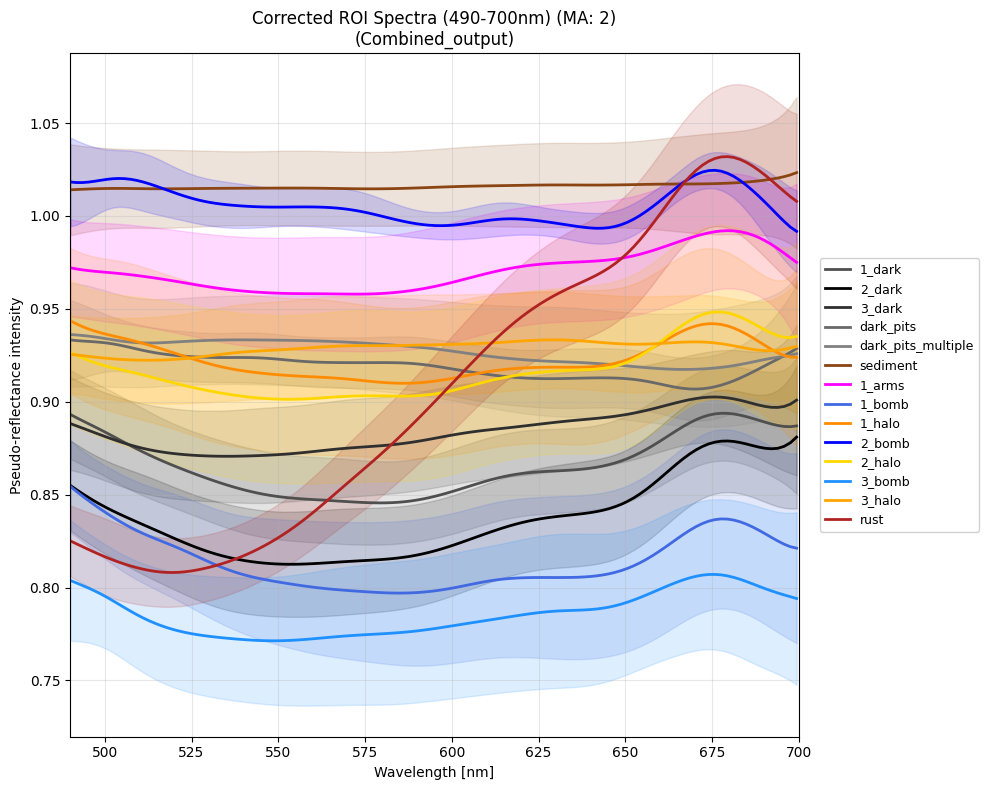

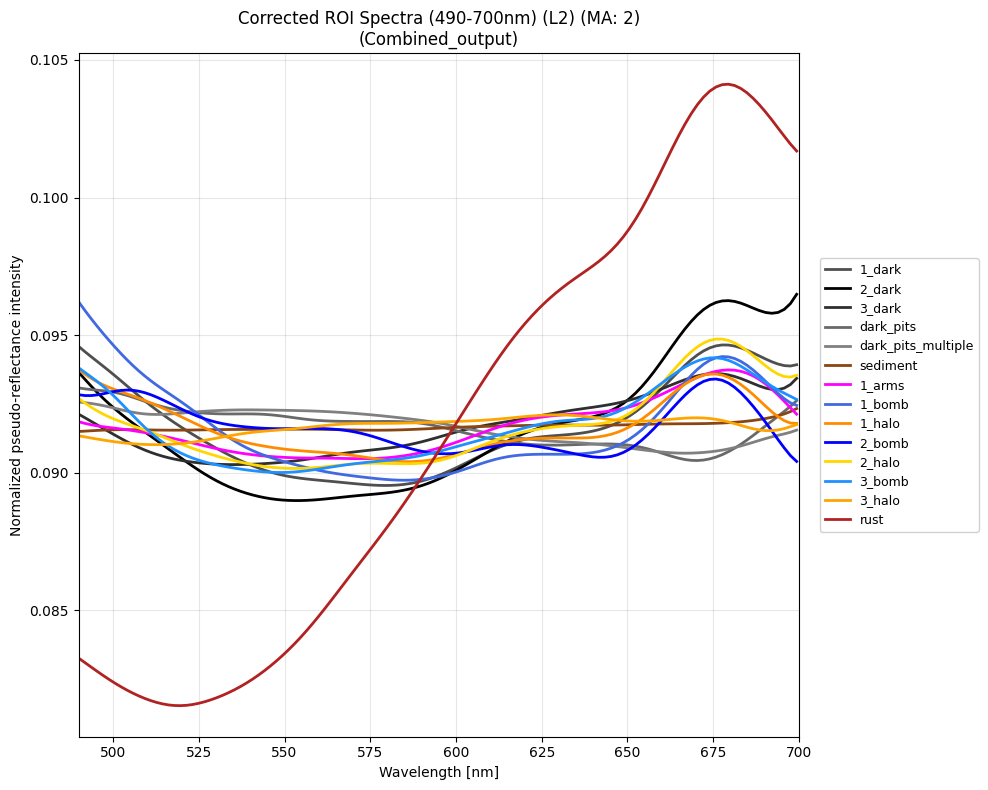

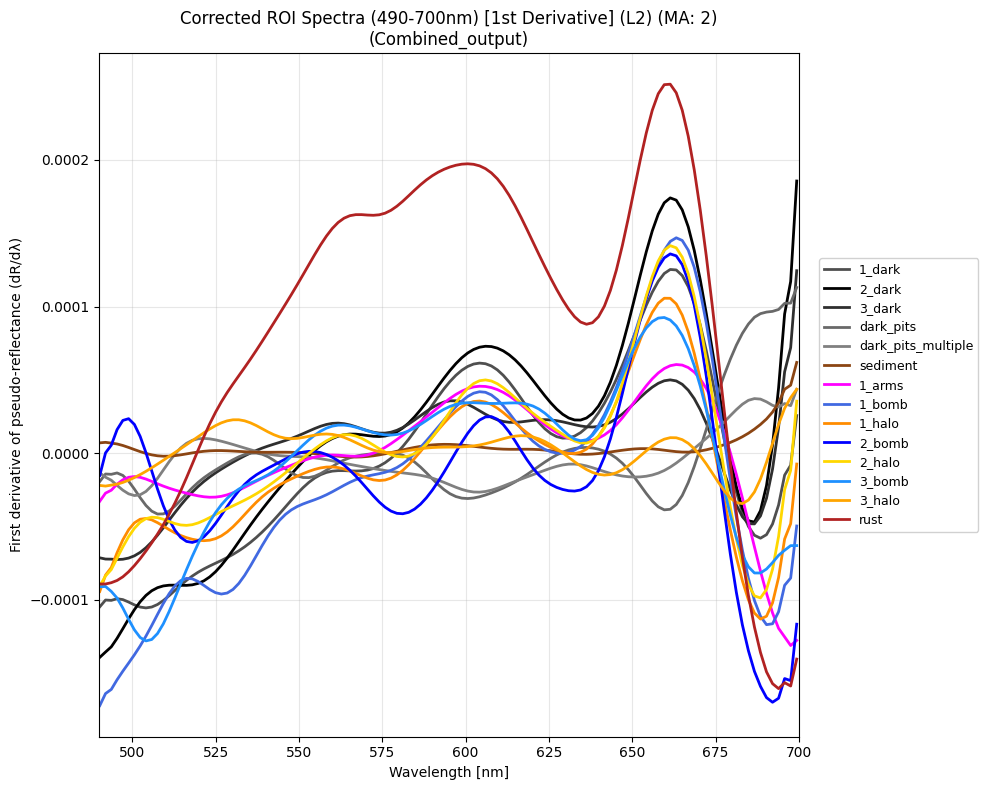

In [8]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Normalized pseudo-reflectance intensity",  # Custom y-axis label
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="First derivative of pseudo-reflectance (dR/dλ)",  # Custom y-axis label
    derivative_order=1,
)

In [9]:
# 🎨 CONFIGURE LEGEND ORDER AND NAMES
# =====================================

# 1. Define which ROIs to exclude from the plot
exclude_rois = ["dark_pits_multiple"]  # Add any ROI names you want to hide

# 2. Define custom display names (optional - leave empty {} to use original names)
roi_display_names = {
    "1_bomb": "bomb a",
    "1_dark": "dark a",
    "1_halo": "halo a",
    "2_bomb": "bomb b",
    "2_dark": "dark b",
    "2_halo": "halo b",
    "3_bomb": "bomb c",
    "3_dark": "dark c",
    "3_halo": "halo c",
    "sediment": "sediment",
    "rust": "rust",
    "1_arms": "radial features a",
    "dark_pits": "dark d",
}

# 3. Define the EXACT ORDER you want in the legend (top to bottom)
legend_order = [
    "1_bomb",
    "1_dark",
    "1_halo",
    "1_arms",
    "2_bomb",
    "2_dark",
    "2_halo",
    "rust",
    "3_bomb",
    "3_dark",
    "3_halo",
    "sediment",
    "dark_pits",
]


# 4. Filter and reorder ROIs based on your settings
def get_ordered_rois(roi_list):
    """Filter, rename, and reorder ROIs based on configuration above."""
    # Filter out excluded ROIs
    filtered = [roi for roi in roi_list if roi not in exclude_rois]

    # Create ordered list based on legend_order
    ordered = []
    for roi_name in legend_order:
        if roi_name in filtered:
            ordered.append(roi_name)

    # Add any remaining ROIs not in legend_order (at the end)
    remaining = [roi for roi in filtered if roi not in ordered]
    ordered.extend(remaining)

    return ordered


print("✅ Legend configuration ready!")
print(f"   Excluded ROIs: {exclude_rois}")
print(f"   Custom names defined: {len(roi_display_names)} ROIs")
print(f"   Legend order: {len(legend_order)} ROIs specified")

✅ Legend configuration ready!
   Excluded ROIs: ['dark_pits_multiple']
   Custom names defined: 13 ROIs
   Legend order: 13 ROIs specified


Available ROIs: ['bomb a', 'dark a', 'halo a', 'radial features a', 'bomb b', 'dark b', 'halo b', 'rust', 'bomb c', 'dark c', 'halo c', 'sediment', 'dark d']

Desired order: ['rust', 'sediment', 'bomb a', 'dark a', 'halo a', 'radial features a', 'bomb b', 'dark b', 'halo b', 'bomb c', 'dark c', 'halo c', 'dark d']

Ordered collection keys: ['rust', 'sediment', 'bomb a', 'dark a', 'halo a', 'radial features a', 'bomb b', 'dark b', 'halo b', 'bomb c', 'dark c', 'halo c', 'dark d']



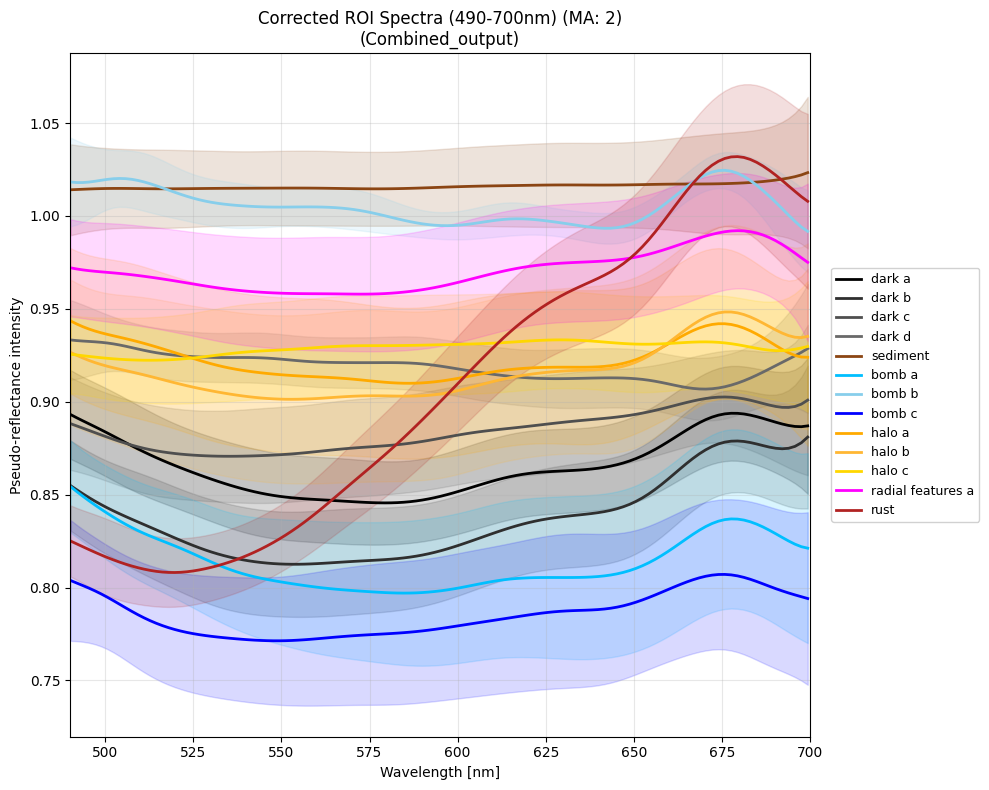

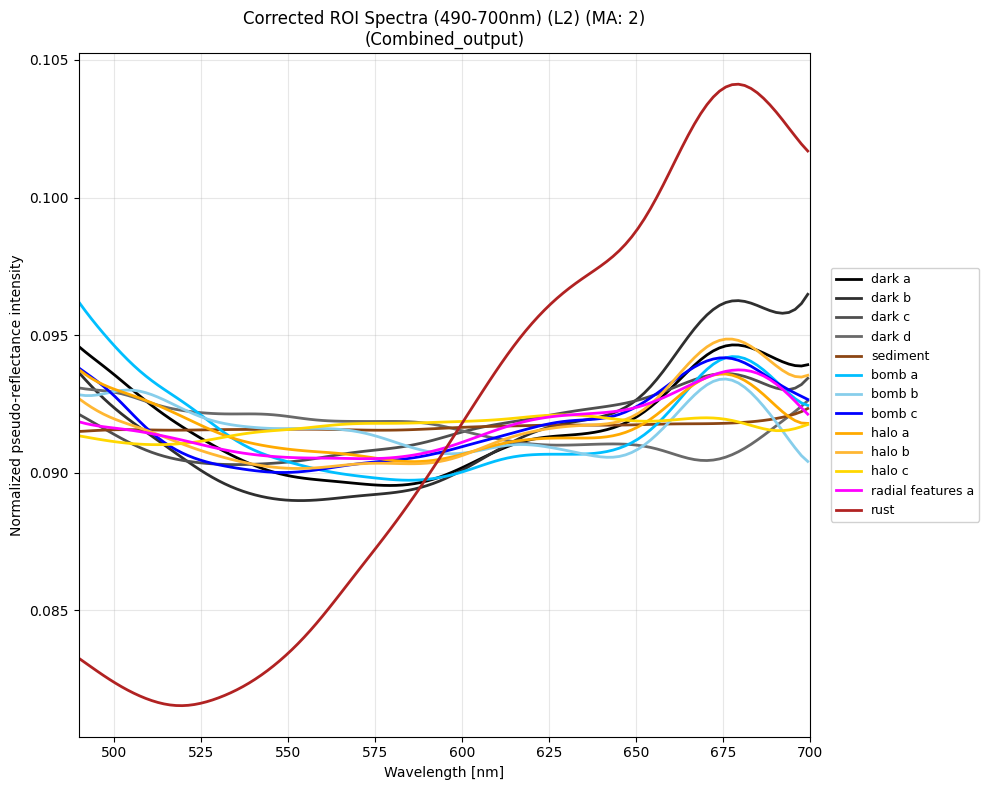

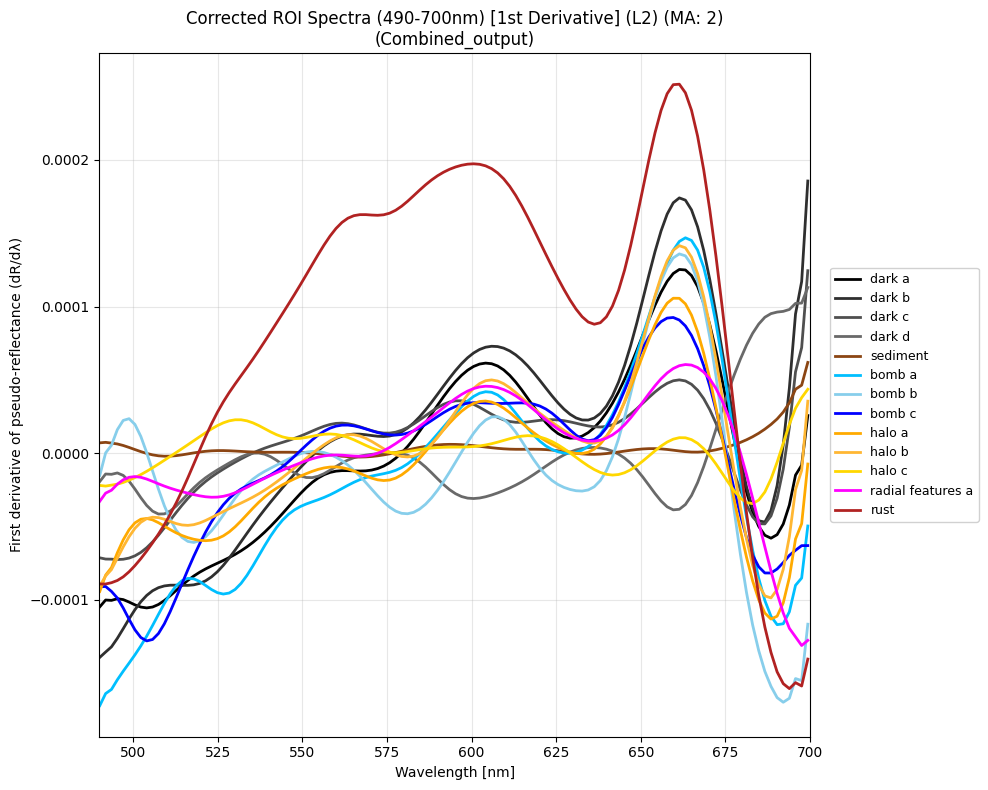

In [12]:
# 📊 Plot spectrum with custom legend order
# ============================================

# Get all ROIs currently loaded
all_rois = list(cube.roi_collection.keys())
print(f"Available ROIs: {all_rois}\n")

# Apply filtering and ordering
ordered_roi_names = get_ordered_rois(all_rois)
print(f"Desired order: {ordered_roi_names}\n")

# CREATE NEW ORDERED ROI COLLECTION (this controls legend order!)
# Python 3.7+ dicts preserve insertion order
ordered_roi_collection = {}
for roi_name in ordered_roi_names:
    if roi_name in cube.roi_collection:
        # Use custom display name if available, otherwise original name
        display_name = roi_display_names.get(roi_name, roi_name)
        ordered_roi_collection[display_name] = cube.roi_collection[roi_name]

print(f"Ordered collection keys: {list(ordered_roi_collection.keys())}\n")

# Temporarily replace ROI collection
original_collection = cube.roi_collection
cube.roi_collection = ordered_roi_collection

# Plot with custom order - legend will match the dictionary order!
cube.plot_spectrum(
    roi_names="all",  # Now "all" will iterate in our custom order
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method=None,
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",
    # legend_loc="lower left",
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Normalized pseudo-reflectance intensity",  # Custom y-axis label
)

cube.plot_spectrum(
    roi_names="all",
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="First derivative of pseudo-reflectance (dR/dλ)",  # Custom y-axis label
    derivative_order=1,
)

# get the leaf image

✨ Manual per-channel normalization applied:
   Red:   [0.5300, 1.3500]
   Green: [0.5800, 1.3700]
   Blue:  [0.2000, 1.7300]
📐 Crop center: global track 9380 → local track 9380, slit 400
   Aspect ratio correction: 10.00:1 (track:slit)
   Slit pixels: 700, Track pixels: 70
🔍 Crop applied: track [9345:9415], slit [50:750]
   Resulting shape: (70, 700, 3)
📊 Extent: x=[50, 750], y=[9345, 9415]
📐 Image shape after transformations: (70, 700, 3)
🐛 DEBUG legend: has_overlays=False, roi_legend_loc=outside, roi_overlay_mode=solid


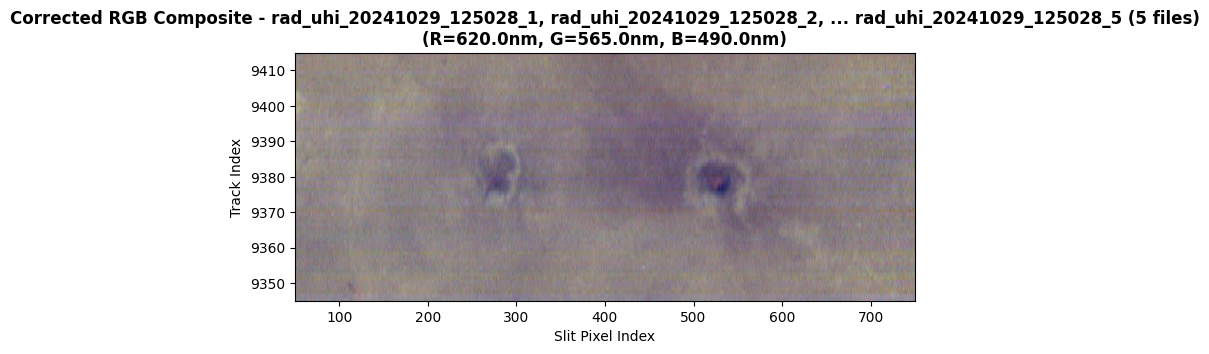

In [11]:
cube.plot_rgb(
    use_corrected=True,
    flip_axes=True,
    flip_horizontal=True,
    crop_center_track=9380,
    crop_center_slit=400,
    crop_width=700,
    show_file_boundaries=False,
    crop_aspect_ratio=10,
    display_aspect_ratio=4.0,
    roi_legend_loc="outside",
    roi_marker_size=5,
    roi_legend_markersize=15,
    roi_marker_edgewidth=0,
    roi_overlay_mode="solid",  # ← Enable solid mode
    roi_solid_pixel_size=1,
)